**Distribucion uniforme**

$E[X] = \int_a^b xp(x)dx = \frac{1}{b-a}\int_a^bxdx$

$E[X] = \frac{1}{b-a}\frac{x²}{2} |_a^b = \frac{1}{b-a}(\frac{b²}{2}-\frac{a²}{2})$

$E[X] = \frac{b^2-a²}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)}$

$E[X] = \frac{a+b}{2}$

$Var(X) = E[X^2] - (E[X])^2)$

$E[X²] = \int_a^b x^2p(x)dx = \frac{1}{b-a}\int_a^bx²dx$

$E[X²] = \frac{1}{b-a}\frac{x³}{3} |_a^b = \frac{1}{b-a}(\frac{b^3}{3}-\frac{a³}{3})$

$E[X²] = \frac{b^3-a³}{3(b-a)} = \frac{(b-a)(b^2+ ab + a²)}{3(b-a)}$

$E[X²] = \frac{a² + ab + b²}{3}$

$Var(X) = E[X^2] - (E[X])^2)$

$= \frac{a² + ab + b²}{3} - (\frac{a+b}{2})² = \frac{(b-a)²}{12}$


**Distribucion Exponencial**

$E[X] = \int_0^{\infty}x\lambda e^{-\lambda x}dx$

$E[X] = [-xe^{-\lambda x}]_0^{\infty} + \int_0^\infty e^{-\lambda x}dx$

$E[x] = [-\frac{e^{-\lambda x}}{\lambda}]_0^{\infty} = \frac{1}{\lambda}$

$Var(X) = E[X^2] - (E[X])^2)$

$E[X²] = \int_0^{\infty}x²\lambda e^{-\lambda x}dx$

$E[X²] = \frac{2}{\lambda²}$

$Var(X) = \frac{2}{\lambda²} - \frac{1}{\lambda²} = \frac{1}{\lambda²}$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1213)  # Semilla aleatoria
N = 100_000          # Tamaño de la muestra
bins = 100          # Cantidad de bines

# Parámetros por distribución
a, b = 0, 1         # Uniforme
lam = 2             # Exponencial (lambda)
mu, sigma = 0, 1

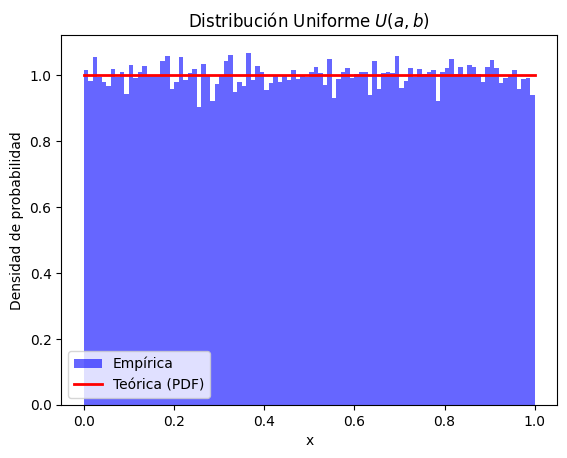

In [2]:
# ==========================================
# 1. DISTRIBUCIÓN UNIFORME
# ==========================================

data_uni = np.random.uniform(a, b, size=N)

plt.hist(data_uni, bins=bins, density=True, alpha=0.6, color='blue', label='Empírica')

x_uni = np.linspace(a, b, 1000)
pdf_uni = np.ones(1000) / (b - a)
plt.plot(x_uni, pdf_uni, 'r-', lw=2, label='Teórica (PDF)')

plt.title('Distribución Uniforme $U(a, b)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

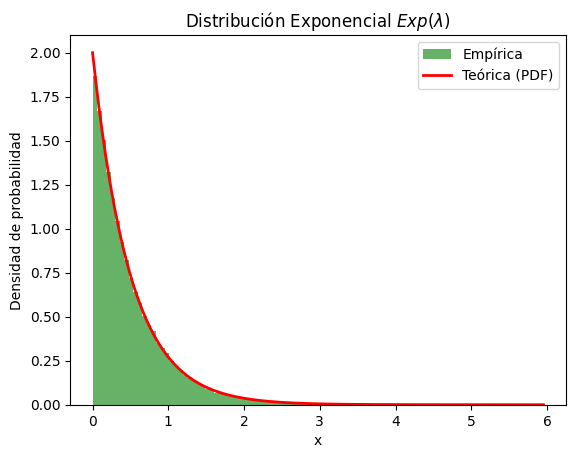

In [3]:
# ==========================================
# 2. DISTRIBUCIÓN EXPONENCIAL
# ==========================================

# El parmetro es scale, no lambda. Entonces scale = 1/lambda
data_exp = np.random.exponential(scale=1.0/lam, size=N)

plt.hist(data_exp, bins=bins, density=True, alpha=0.6, color='green', label='Empírica')

x_exp = np.linspace(0, max(data_exp), 1000)
pdf_exp = lam * np.exp(-lam * x_exp)
plt.plot(x_exp, pdf_exp, 'r-', lw=2, label='Teórica (PDF)')


plt.title('Distribución Exponencial $Exp(\\lambda)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

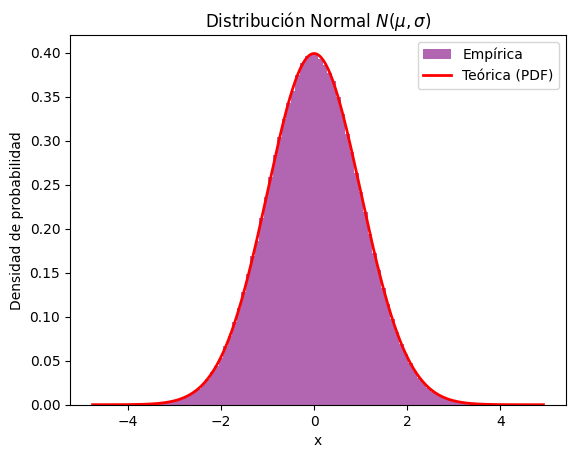

In [6]:
# ==========================================
# 3. DISTRIBUCIÓN GAUSSIANA (NORMAL)
# ==========================================

data_gauss = np.random.normal(loc=mu, scale=sigma, size=N)

plt.hist(data_gauss, bins=bins, density=True, alpha=0.6, color='purple', label='Empírica')
x_gauss = np.linspace(min(data_gauss), max(data_gauss), 1000)

pdf_gauss = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gauss - mu) / sigma)**2)
plt.plot(x_gauss, pdf_gauss, 'r-', lw=2, label='Teórica (PDF)')


plt.title('Distribución Normal $N(\\mu, \\sigma)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

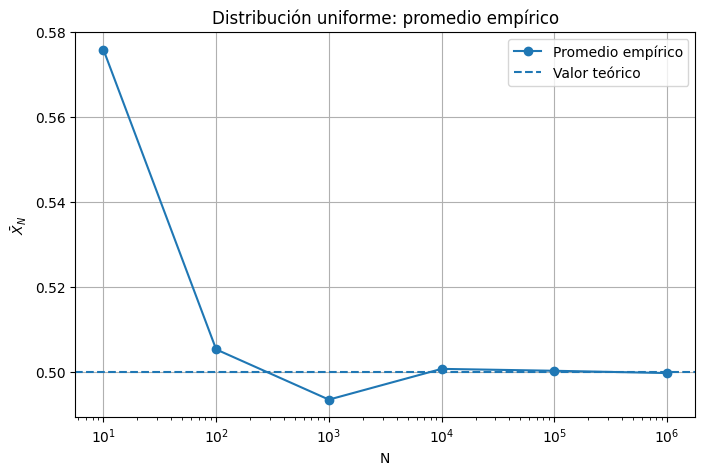

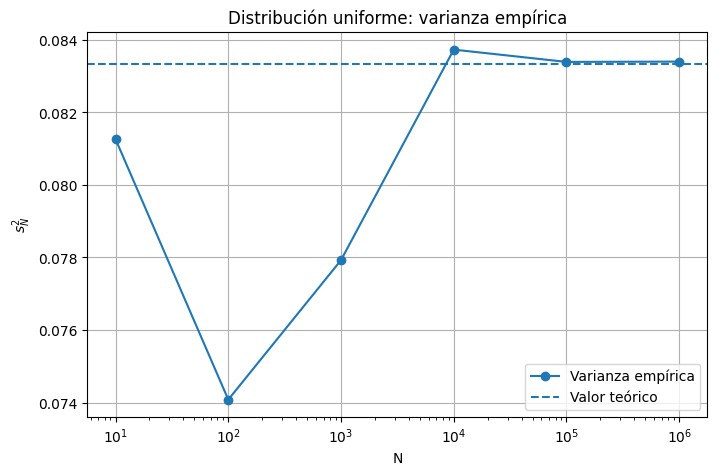

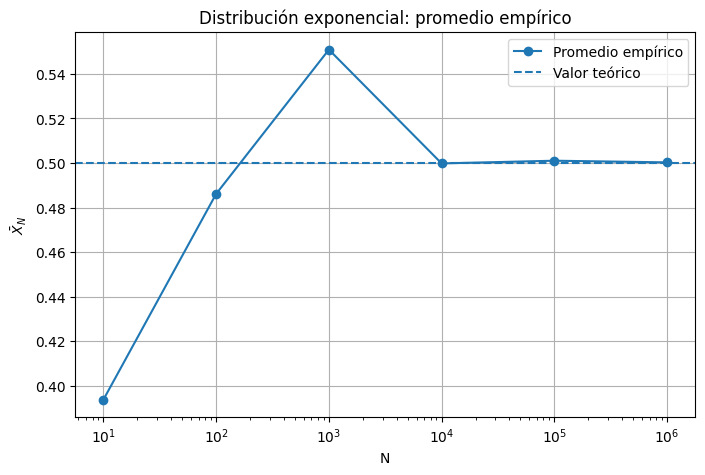

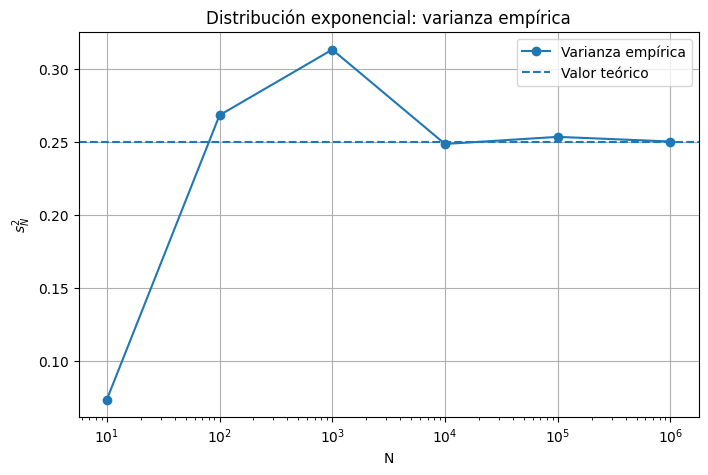

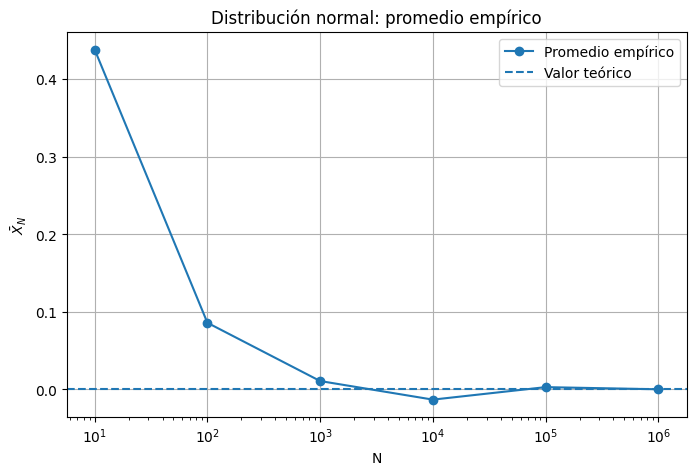

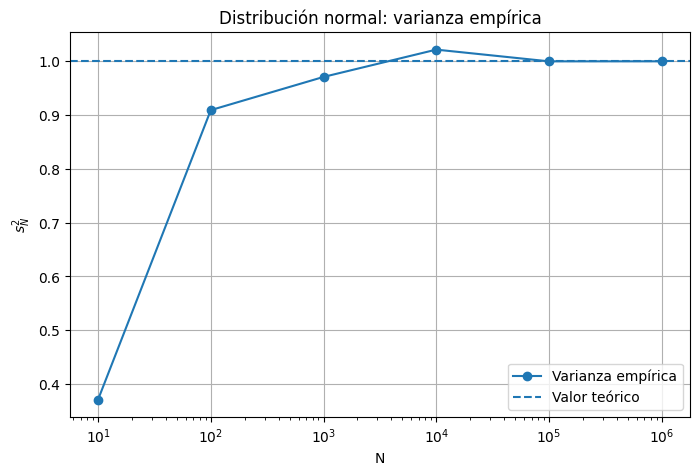

In [7]:

a = 0
b = 1

lam = 2

mu = 0
sigma = 1

N_values = [10, 100, 1000, 10000, 100000, 1000000]

media_uni_teo = (a + b)/2
var_uni_teo = (b - a)**2 / 12

media_exp_teo = 1/lam
var_exp_teo = 1/lam**2

media_norm_teo = mu
var_norm_teo = sigma**2

def estadisticas(datos):
    media = np.mean(datos)
    varianza = np.mean((datos - media)**2)
    return media, varianza

medias_uni = []
vars_uni = []

for N in N_values:

    datos = np.random.uniform(a, b, N)

    media, var = estadisticas(datos)

    medias_uni.append(media)
    vars_uni.append(var)

medias_exp = []
vars_exp = []

for N in N_values:

    datos = np.random.exponential(scale=1/lam, size=N)

    media, var = estadisticas(datos)

    medias_exp.append(media)
    vars_exp.append(var)

medias_norm = []
vars_norm = []

for N in N_values:

    datos = np.random.normal(mu, sigma, N)

    media, var = estadisticas(datos)

    medias_norm.append(media)
    vars_norm.append(var)

plt.figure(figsize=(8,5))

plt.plot(N_values, medias_uni, 'o-', label='Promedio empírico')
plt.axhline(media_uni_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$\bar{X}_N$')
plt.title('Distribución uniforme: promedio empírico')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(N_values, vars_uni, 'o-', label='Varianza empírica')
plt.axhline(var_uni_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$s_N^2$')
plt.title('Distribución uniforme: varianza empírica')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(N_values, medias_exp, 'o-', label='Promedio empírico')
plt.axhline(media_exp_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$\bar{X}_N$')
plt.title('Distribución exponencial: promedio empírico')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(N_values, vars_exp, 'o-', label='Varianza empírica')
plt.axhline(var_exp_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$s_N^2$')
plt.title('Distribución exponencial: varianza empírica')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(N_values, medias_norm, 'o-', label='Promedio empírico')
plt.axhline(media_norm_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$\bar{X}_N$')
plt.title('Distribución normal: promedio empírico')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(N_values, vars_norm, 'o-', label='Varianza empírica')
plt.axhline(var_norm_teo,
            linestyle='--',
            label='Valor teórico')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$s_N^2$')
plt.title('Distribución normal: varianza empírica')
plt.legend()
plt.grid()
plt.show()